Loading networks/small_network/simulation/output.hdf5
WARNING. Depolarisation block in neuron - neuron_id: (name, parameter_key, morphology_key):
128: (dSPN_1, p9faf904a, m71f9efc2)
150: (dSPN_1, p4279b59f, mc44c4566)
168: (dSPN_1, p9faf904a, m82894e90)
201: (dSPN_1, p9faf904a, m71f9efc2)
249: (dSPN_1, p9faf904a, m82894e90)
500: (FS_0, p15a0c229, mb1b67bcc)
506: (FS_1, pf9439e45, mf0a83676)
515: (FS_3, p4ce0645d, m127c582f)
Saving figure to networks/small_network/figures/spike-raster.png


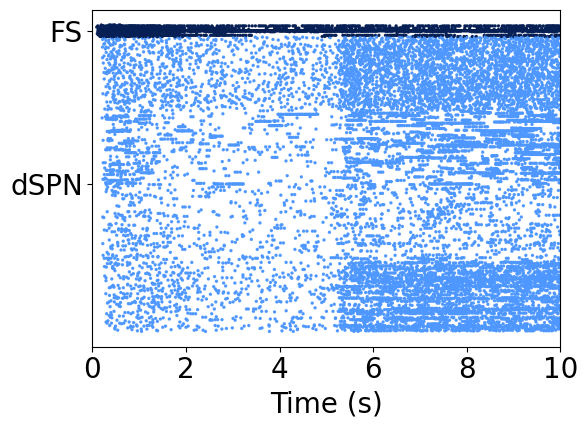

In [11]:
import os
from snudda.plotting import SnuddaPlotSpikeRaster2

network_path = "networks/small_network"
network_file = os.path.join(network_path, "network-synapses.hdf5")
sim_file = os.path.join(network_path, "simulation", "output.hdf5")

fig_file_raster = f"spike-raster.png"

spr = SnuddaPlotSpikeRaster2(network_path=network_path,
                             network_file=network_file,
                             simulation_file=sim_file)

spr.plot_spike_raster(fig_file=fig_file_raster, time_range=(0,10))

Writing figure networks/small_network/figures/spike_frequency_histogram.png


/home/hjorth/HBP/Snudda/snudda/plotting/plot_spike_raster_v2.py:350: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc=legend_loc, bbox_to_anchor=bbox_anchor)


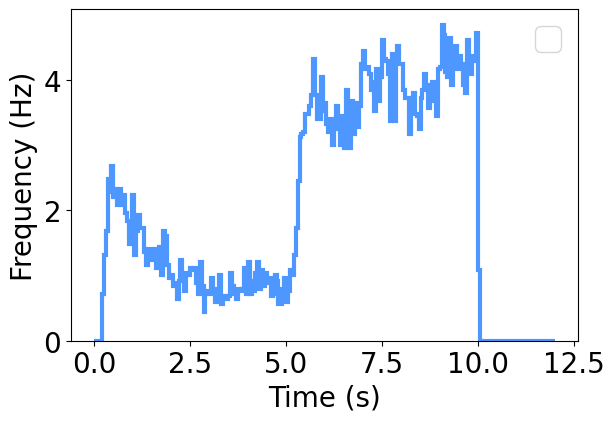

<Axes: xlabel='Time (s)', ylabel='Frequency (Hz)'>

In [2]:
spr.plot_spike_histogram_type(neuron_type=["dSPN"], fig_file="spike_frequency_histogram.png")


In [3]:
from snudda.utils import SnuddaLoadSimulation

nd = SnuddaLoadSimulation(sim_file)
time = nd.get_time()

neuron_id = 50
data_types = nd.list_data_types(neuron_id)
all_species_data = nd.get_all_data(neuron_id=neuron_id, exclude=["spikes", "voltage"])

Loading networks/small_network/simulation/output.hdf5
WARNING. Depolarisation block in neuron - neuron_id: (name, parameter_key, morphology_key):
128: (dSPN_1, p9faf904a, m71f9efc2)
150: (dSPN_1, p4279b59f, mc44c4566)
168: (dSPN_1, p9faf904a, m82894e90)
201: (dSPN_1, p9faf904a, m71f9efc2)
249: (dSPN_1, p9faf904a, m82894e90)
500: (FS_0, p15a0c229, mb1b67bcc)
506: (FS_1, pf9439e45, mf0a83676)
515: (FS_3, p4ce0645d, m127c582f)


In [4]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "iframe"  # Do not save plots in the notebook, they can get BIG



fig = go.Figure()
for data_type in all_species_data:
    idx = time >= 0.0
    fig.add_trace(go.Scatter(x=time[idx], y=all_species_data[data_type][0][neuron_id].T[0][idx], name=data_type, line={"width":4}))

"""
fig.update_layout(xaxis_title="Time (s)", yaxis_title="Concentration", width=1000, height=800,
                 font={"size":18},  # General font size for all elements
                 legend={"font":{"size":16}},  # Specific font size for legend
                 xaxis={"title":{"font":{"size":20}}, "tickfont":{"size":14}},  # X-axis title and tick labels
                 yaxis={"title":{"font":{"size":20}}, "tickfont":{"size":14}})   # Y-axis title and tick labels
"""
fig.show()

In [5]:
# Reporting plot

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "iframe"  # Do not save plots in the notebook, they can get BIG

fig = go.Figure()
for data_type in ["D1RDA", "PKAc", "cAMP"]: #all_species_data:
    idx = time >= 0.0
    fig.add_trace(go.Scatter(x=time[idx], y=all_species_data[data_type][0][neuron_id].T[0][idx], name=data_type, line={"width":4}))

fig.update_layout(xaxis_title="Time (s)", yaxis_title="Concentration", width=1000, height=800,
                  font={"size":18},  # General font size for all elements
                  legend={"font":{"size":50}},  # Specific font size for legend
                  xaxis={"title":{"font":{"size":40}}, "tickfont":{"size":30}},  # X-axis title and tick labels
                  yaxis={"title":{"font":{"size":40}}, "tickfont":{"size":30}})   # Y-axis title and tick labels


fig.show()

fig.write_image("example-da-cascade-1.png", width=1200, height=800)


In [9]:
fig2 = go.Figure()
for data_type in ["cal12_ms.modulation_factor", "cal13_ms.modulation_factor", "car_ms.modulation_factor", "car_ms.modulation_factor2",
                  "kas_ms.modulation_factor", "kir_ms.modulation_factor", "kaf_ms.modulation_factor_g", "kaf_ms.modulation_factor_shift",
                  "naf_ms.modulation_factor", 
                  "sk_ms.modulation_factor"]: #all_species_data:
    idx = time >= 0.0
    data_type_str = data_type.replace("modulation_factor", "modulation")
    fig2.add_trace(go.Scatter(x=time[idx], y=all_species_data[data_type][0][neuron_id].T[0][idx], name=data_type_str, line={"width":4}))

fig2.update_layout(xaxis_title="Time (s)", yaxis_title="Modulation factor", width=1000, height=800,
                  font={"size":18},  # General font size for all elements
                  legend={"font":{"size":20}},  # Specific font size for legend
                  xaxis={"title":{"font":{"size":40}}, "tickfont":{"size":30}},  # X-axis title and tick labels
                  yaxis={"title":{"font":{"size":40}}, "tickfont":{"size":30}})   # Y-axis title and tick labels

fig2.show()
fig2.write_image("example-da-cascade-2-effect.png", width=1200, height=800)